# ДЗ-4

В этой работе вам предстоит закрепить основные команды взаимодействия с открытыми API.

За это задание можно получить до 8 баллов (включительно).

Код можно писать в нескольких ячейках.

## Задание "Карточные фокусы"

В этом задании вам предстоит взаимодействите с открытым API: `https://deckofcardsapi.com`

Основные эндпойнты:
1. Создать стопку из `N` колод кард по 52 карты каждая

`https://deckofcardsapi.com/api/deck/new/shuffle/?deck_count=N` (вместо `N` нужно вставить свое число)

После вызова метода будет возвращен `json`, из которого основной информацией будет значение по ключу `deck_id`


Пример: `get` запроса `"https://deckofcardsapi.com/api/deck/new/shuffle/?deck_count=3"` вернет
```json
{
    "success": true,
    "deck_id": "lcww1uui6bf6",
    "remaining": 156,
    "shuffled": true
}
```


2. Метод извлечения `N` карт из созданной колоды по `deck_id`


Пример: `get` запрос `https://deckofcardsapi.com/api/deck/lcww1uui6bf6/draw/?count=2` вернет
```json
{
    "success": true,
    "deck_id": "lcww1uui6bf6",
    "cards": [
        {
            "code": "7H",
            "image": "https://deckofcardsapi.com/static/img/7H.png",
            "images": {
                "svg": "https://deckofcardsapi.com/static/img/7H.svg",
                "png": "https://deckofcardsapi.com/static/img/7H.png"
            },
            "value": "7",
            "suit": "HEARTS"
        },
        {
            "code": "3C",
            "image": "https://deckofcardsapi.com/static/img/3C.png",
            "images": {
                "svg": "https://deckofcardsapi.com/static/img/3C.svg",
                "png": "https://deckofcardsapi.com/static/img/3C.png"
            },
            "value": "3",
            "suit": "CLUBS"
        }
    ],
    "remaining": 154
}
```

Обратите внимание, после извлечения карты не возвращаются в колоду.

### Описание структуры JSON

Основные поля `json` при создании колоды:
* remaining - количество карт, которые остались в колоде (уменьшается при извлечении)
* deck_id - идентификатор созданной колоды
* shuffled - флаг того, что колода перемешана или нет
* success - флаг того, что метод все завершилось корректно

При вызове метода на извлечение карт из колоды добавляются поля:
* cards - список извлеченных карт с описанием

Описание карты:
* code - код карты (составлен из номинала и первой буквы масти)
* image - ссылка на изображение в .png формате
* images - список других форматов изображений (.png и .svg)
* value - значение карты
* suit - масть

### Задача 1 (1 балл)

Напишите фупрограмму, которая запрашивает по API создание колоды из четырех мастей. Извлеките идентификатор колоды для дальнейшей работы и выведите структуру `json`, которая вам поступает в ответ, а таже статус-код.

In [ ]:
import requests
import json
url = "https://deckofcardsapi.com/api/deck/new/shuffle/?deck_count=1"

response = requests.get(url)
print("код:", response.status_code)
d = response.json()
print("\nJSON-ответ:")
print(json.dumps(d, indent=4))
de_id = d.get("deck_id")
print("\ИДЕНТ:", de_id)


код: 200

JSON-ответ:
{
    "success": true,
    "deck_id": "vxwxr006mucn",
    "remaining": 52,
    "shuffled": true
}
\ИДЕНТ: vxwxr006mucn


### Задача 2.1 (1 балл)

Извлеките из колоды десять карт. Рекомендуется использовать такой способ создания url ссылки, чтобы изменять отдельно параметры запроса

```python
deck_id = data['deck_id']
number_of_cards = 10

url = f"https://deckofcardsapi.com/api/deck/{deck_id}/draw/?count={number_of_cards}"
```

In [ ]:
import requests
import json
url = "https://deckofcardsapi.com/api/deck/new/shuffle/?deck_count=1"
response = requests.get(url)
print("СТАТУС:", response.status_code)

data = response.json()
print("\-ответ:")
print(json.dumps(data, indent=4))

# --- 2. Извлекаем deck_id ---
deck_id = data.get("deck_id")
print("\nИдент:", deck_id)

# --- 3. Формируем URL для вытягивания 10 карт ---
dc = 10
du = f"https://deckofcardsapi.com/api/deck/{deck_id}/draw/?count={dc}"

# --- 4. Запрос на вытягивание карт ---
dr = requests.get(du)
print("\запрос:", dr.status_code)

dd = dr.json()
print("\nJSON-ответ при вытягивании карт:")
print(json.dumps(dd, indent=4))

# --- 5. Вывод карт ---
cards = dd.get("cards", [])
print(f"\nИзвлеченные карты ({len(cards)}):")
for card in cards:
    print(f"{card['value']} of {card['suit']} (code: {card['code']})")


<>:8: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipython-input-3216315241.py:8: SyntaxWarning: invalid escape sequence '\-'
  print("\-ответ:")


СТАТУС: 200
\-ответ:
{
    "success": true,
    "deck_id": "pg6jmwz5dazr",
    "remaining": 52,
    "shuffled": true
}

Идент: pg6jmwz5dazr
\запрос: 200

JSON-ответ при вытягивании карт:
{
    "success": true,
    "deck_id": "pg6jmwz5dazr",
    "cards": [
        {
            "code": "2H",
            "image": "https://deckofcardsapi.com/static/img/2H.png",
            "images": {
                "svg": "https://deckofcardsapi.com/static/img/2H.svg",
                "png": "https://deckofcardsapi.com/static/img/2H.png"
            },
            "value": "2",
            "suit": "HEARTS"
        },
        {
            "code": "AS",
            "image": "https://deckofcardsapi.com/static/img/AS.png",
            "images": {
                "svg": "https://deckofcardsapi.com/static/img/AS.svg",
                "png": "https://deckofcardsapi.com/static/img/AS.png"
            },
            "value": "ACE",
            "suit": "SPADES"
        },
        {
            "code": "3S",
    

### Задача 2.2 (2 балла)

Среди всех карт в `cards` соберите информацию о том, сколько карт каждой масти было вытянуто. Выведите это в консоль.

In [ ]:
s = {}

for card in cards:
    suit = card["suit"]
    s[suit] = s.get(suit, 0) + 1

print("\колво:")
for suit, count in s.items():
    print(f"{suit}: {count}")

\колво:
HEARTS: 3
SPADES: 3
CLUBS: 3
DIAMONDS: 1


### Задача 2.3 (1 балл)

Определите наибольший номинал среди вытащенныз карт и ее масть.

In [ ]:
rank_values = {
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "10": 10,
    "JACK": 11,
    "QUEEN": 12,
    "KING": 13,
    "ACE": 14
}

mx = max(cards, key=lambda c: rank_values[c["value"]])

print("наибол:")
print(f"{mx['value']} of {mx['suit']}")



наибол:
ACE of SPADES


### Задача 2.4 (2 балла)

Повторите еще десять извлечений по 10 карт. Создайте датафрейм в `pandas`, в котором столбцами будут названия мастей, а в строках - количество вытянутых карт каждой масти соответственно.


Постройте накопительную диаграмму по вытянутым значениям. Код ниже как раз строит такую диаграмму.


df:
         HEARTS  DIAMONDS  CLUBS  SPADES
Draw 1        3         2      1       4
Draw 2        2         1      5       2
Draw 3        6         2      1       1
Draw 4        2         1      3       4
Draw 5        0         6      2       2
Draw 6        0         1      1       0
Draw 7        0         0      0       0
Draw 8        0         0      0       0
Draw 9        0         0      0       0
Draw 10       0         0      0       0


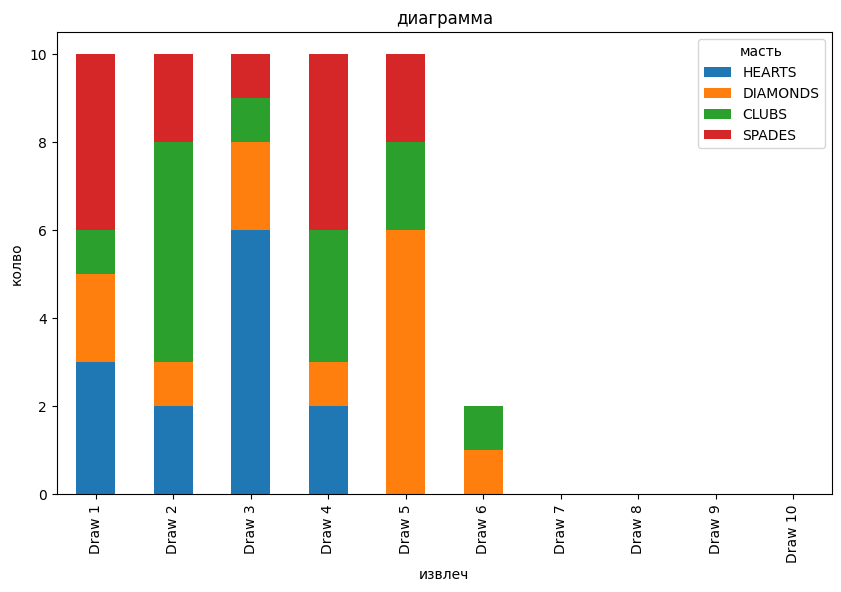

In [ ]:
from os import sched_get_priority_max
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
create_url = "https://deckofcardsapi.com/api/deck/new/shuffle/?deck_count=1"
response = requests.get(create_url)
d = response.json()
deck_id = d.get("deck_id")
extract_counts = []

for i in range(10):
    du = f"https://deckofcardsapi.com/api/deck/{deck_id}/draw/?count=10"
    dr = requests.get(du)
    dd = dr.json()
    cards = dd.get("cards", [])
    sc = {"HEARTS": 0, "DIAMONDS": 0, "CLUBS": 0, "SPADES": 0}
    for card in cards:
        sc[card["suit"]] += 1

    extract_counts.append(sc)
df = pd.DataFrame(extract_counts)
df.index = [f"Draw {i+1}" for i in range(10)]
print("\ndf:")
print(df)
df.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("диаграмма")
plt.xlabel("извлеч")
plt.ylabel("колво")
plt.legend(title="масть")
plt.show()


### Задача 2.5 (1 балл)

На основе данный в предыдущем пункте, постройте график частоты встречаемости для каждой масти по измерениям, т.е. поделите количество на 10 и построить графики.

\частота:
         HEARTS  DIAMONDS  CLUBS  SPADES
Draw 1      0.3       0.2    0.1     0.4
Draw 2      0.2       0.1    0.5     0.2
Draw 3      0.6       0.2    0.1     0.1
Draw 4      0.2       0.1    0.3     0.4
Draw 5      0.0       0.6    0.2     0.2
Draw 6      0.0       0.1    0.1     0.0
Draw 7      0.0       0.0    0.0     0.0
Draw 8      0.0       0.0    0.0     0.0
Draw 9      0.0       0.0    0.0     0.0
Draw 10     0.0       0.0    0.0     0.0


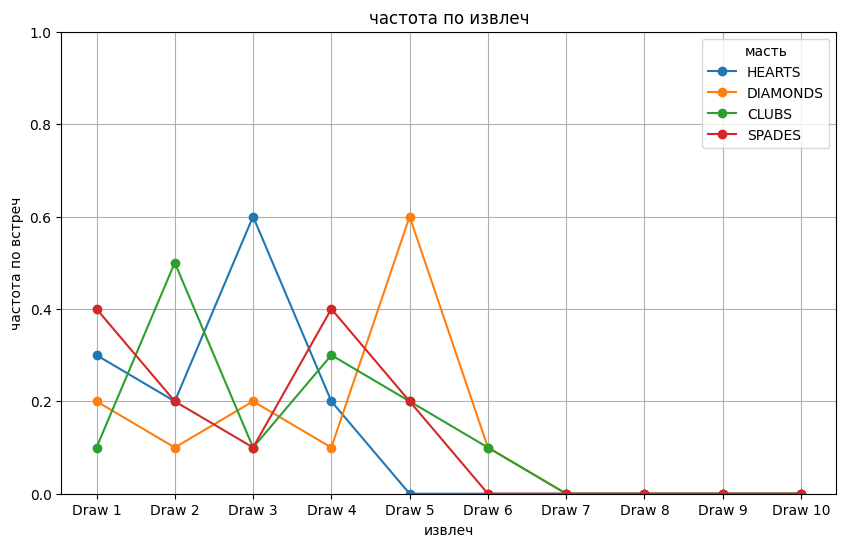

In [ ]:
import matplotlib.pyplot as plt
df_f = df / 10.0

print("\частота:")
print(df_f)
plt.figure(figsize=(10,6))
for suit in df_f.columns:
    plt.plot(df_f.index, df_f[suit], marker='o', label=suit)

plt.title("частота по извлеч")
plt.xlabel("извлеч")
plt.ylabel("частота по встреч")
plt.ylim(0, 1)
plt.legend(title="масть")
plt.grid(True)
plt.show()